In [300]:
import pandas as pd
import numpy as np
from openai import OpenAI
from palmerpenguins import load_penguins
import re
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [301]:
# Setting up connection to LM Studio

client = OpenAI (
    base_url='http://localhost:1234/v1',
    api_key='lm_studio' 
)

In [302]:
# Loading data

penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [303]:
# Building function to prompt model with preprogrammed context, and extract and run code

context = f'''
<role>
You are an expert data science assistant helping analyze a pandas dataframe.
Your role is not to import libraries. Your role involves selecting functions from the list of functions in the given constraints and running them.
Never import libraries.
</role>

<context>
The dataframe is called `penguins` and is already loaded.

<columns>
{penguins.dtypes}
</columns>

<sample_data>
{penguins.head(3).to_string()}
</sample_data>
</context>

<format>
Always return code in a ```python code block.
</format>

<constraints>
Use only these libraries: pandas as pd, seaborn as sns, matplotlib.pyplot as plt, and sklearn.
Always use the variable name `penguins`. Never rename it.
Do not include import statements in your code. Never import libraries. All necessary libraries are already imported.
</constraints>
'''

def q(prompt):

    # Sending requests to Gemma via local LM Studio API
    response = client.chat.completions.create(
        model='google/gemma-3-12b', # Specifying model
        messages=[ # Establishing required conversation parameters
            {'role': 'system', 'content': context}, # Preprogrammed context
            {'role': 'user', 'content': f'<task>{prompt}</task>'} # User prompt wrapped in XML tags
        ],
        max_tokens=500 # Limiting length of response
    )
    result = response.choices[0].message.content # Extracting text from API response object
    code_blocks = re.findall(r'```python(.*?)```', result, re.DOTALL) # Isolating the Python code using regex
    
    if code_blocks: # Checking if there is any code
        for code in code_blocks: # Looping through the extracted code
            display(Markdown(f'```python{code}```')) # Showing the code to be run
            get_ipython().run_cell(code.strip()) # Running the code
    else: 
        display(Markdown(result)) # Showing the whole response as markdown in the absence of detectable code

# EDA

In [304]:
q('Which pandas functions are most useful for analyzing this dataset?')

Here's a breakdown of pandas functions that would be highly useful for analyzing the `penguins` dataset, along with explanations:

1.  **`.head()` and `.tail()`:** These are essential for quickly inspecting the first or last few rows of the dataframe to get a feel for the data's structure and content.

2.  **`.info()`:** Provides a concise summary of the dataframe, including data types, non-null counts (handling missing values), and memory usage. This is crucial for understanding the data's characteristics before deeper analysis.

3.  **`.describe()`:** Generates descriptive statistics (count, mean, standard deviation, min, max, quartiles) for numerical columns.  This gives a good overview of the central tendency, spread, and range of values in those columns.

4.  **`.isnull().sum()`:**  Calculates the number of missing values in each column, helping identify potential data quality issues.

5.  **`.groupby()`:** This is a powerful function for grouping rows based on one or more columns (e.g., `species`, `island`).  You can then apply aggregate functions to each group (see below).

6.  **Aggregate Functions (`.mean()`, `.median()`, `.sum()`, `.count()`, `.min()`, `.max()`):**  These functions are often used in conjunction with `groupby()` to calculate summary statistics for each group. For example, you could find the average bill length for each species.

7.  **`.value_counts()`:** Useful for categorical columns (like `species`, `island`, and `sex`) to determine the frequency of each unique value.

8.  **`.dropna()` and `.fillna()`:** For handling missing data, `dropna()` removes rows with any missing values (use cautiously), while `fillna()` replaces missing values with a specified value (e.g., the mean or median).

9.  **`.sort_values()`:** Sorts the dataframe based on one or more columns, which can be helpful for identifying trends or outliers.

10. **`.astype()`:**  Converts the data type of a column (e.g., from integer to float).

11. **`.apply()`:** Applies a function to each element or column of the dataframe, allowing for custom data transformations.

12. **`.corr()`:** Calculates the

In [305]:
q('number of rows containing nulls')

```python
print(penguins.isnull().sum().sum())
```

19


In [306]:
q('names of columns that contain nulls')

```python
penguins.columns[penguins.isnull().any()].tolist()
```

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

In [307]:
q('number of nulls each of these columns contains: bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, sex ')

```python
null_counts = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']].isnull().sum()
print(null_counts)
```

bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [308]:
q('value counts normalized of sex column grouped by species')

```python
penguins.groupby('species')['sex'].value_counts(normalize=True)
```

species    sex   
Adelie     male      0.500000
           female    0.500000
Chinstrap  female    0.500000
           male      0.500000
Gentoo     male      0.512605
           female    0.487395
Name: proportion, dtype: float64

In [309]:
# Project goal is predictive modeling of species. Since sex column evenly balanced by species and contains the largest number of nulls, dropping that column.

q('drop the sex column')

```python
penguins = penguins.drop('sex', axis=1)
```

In [310]:
# Checking number of nulls in remaining null-containing columns

q('number of nulls each of these columns contains: bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g')

```python
penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].isnull().sum()
```

bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64

In [311]:
# Checking to see if the remaining nulls are distributed about or occur within the same records

q('show the full rows containing nulls')

```python
penguins[penguins.isnull().any(axis=1)]
```

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,2009


In [312]:
# The remaining nulls are only in two rows--dropping them

q('drop rows containing nulls')

```python
penguins = penguins.dropna()
```

```python
sns.countplot(x='species', data=penguins)
plt.show()
```

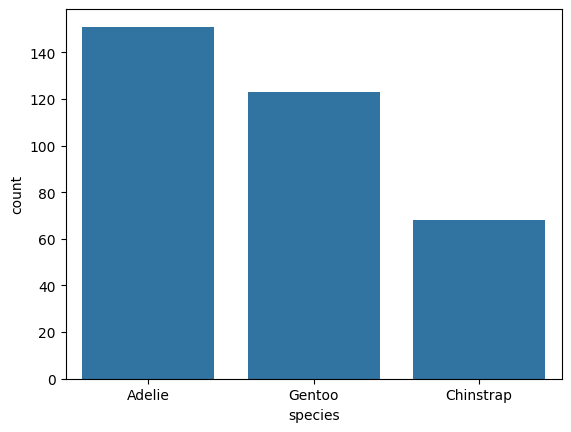

In [313]:
q('bar graph of count for each species')

```python
penguins.hist(column='flipper_length_mm')
```

array([[<Axes: title={'center': 'flipper_length_mm'}>]], dtype=object)

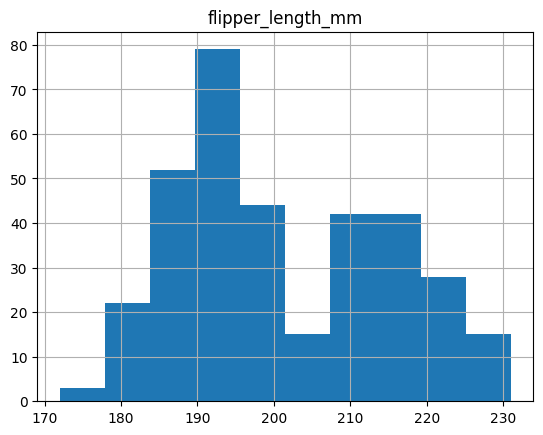

In [314]:
q('histogram of flipper length')

```python
sns.histplot(data=penguins, x="flipper_length_mm", hue="species", bins=20)
plt.show()
```

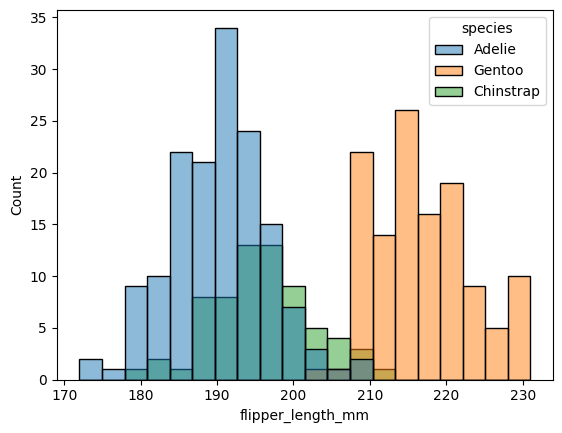

In [315]:
q('histogram of flipper length with hue for species')

In [316]:
q('average body mass')

```python
penguins['body_mass_g'].mean()
```

np.float64(4201.754385964912)

In [317]:
q('summary statistics for bill depth')

```python
penguins['bill_depth_mm'].describe()
```

count    342.000000
mean      17.151170
std        1.974793
min       13.100000
25%       15.600000
50%       17.300000
75%       18.700000
max       21.500000
Name: bill_depth_mm, dtype: float64

In [318]:
q('summary statistics for bill depth by species')

```python
penguins.groupby('species')['bill_depth_mm'].describe()
```

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,151.0,18.346358,1.216650,15.5,17.5,18.40,19.0,21.5
Chinstrap,68.0,18.420588,1.135395,16.4,17.5,18.45,19.4,20.8
Gentoo,123.0,14.982114,0.981220,13.1,14.2,15.00,15.7,17.3


In [319]:
q('distribution of species among the different islands')

```python
island_counts = penguins.groupby('island')['species'].value_counts()
print(island_counts)
```

island     species  
Biscoe     Gentoo       123
           Adelie        44
Dream      Chinstrap     68
           Adelie        56
Torgersen  Adelie        51
Name: count, dtype: int64


```python
sns.scatterplot(x="body_mass_g", y="flipper_length_mm", hue="species", data=penguins)
```

<Axes: xlabel='body_mass_g', ylabel='flipper_length_mm'>

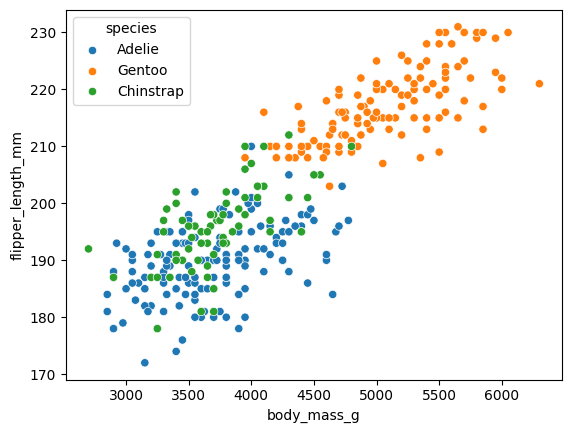

In [320]:
q('scatterplot of body mass against flipper length with species as hue')

In [321]:
q('create a new column called island_encoded by encoding the island column')

```python
penguins['island_encoded'] = penguins['island'].astype('category').cat.codes
```

In [322]:
q('create a new column called species_encoded by encoding the species column')

```python
penguins['species_encoded'] = penguins['species'].astype('category').cat.codes
```

```python
numerical_cols = penguins.select_dtypes(include=['number']).columns
correlation_matrix = penguins[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()
```

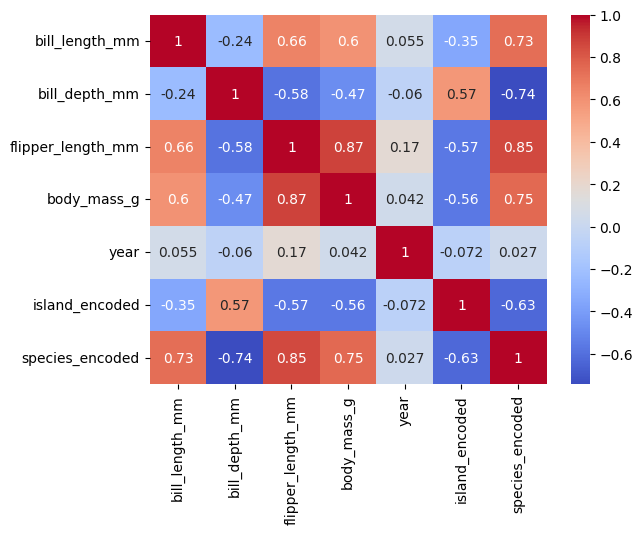

In [323]:
q('heatmap of all numerical variables. not all variables are numerical. deal with this before creating heatmap')

## Preparing for modeling

In [324]:
# Creating list of features

q('create a variable called features that is a list of all numerical variables except year and species_encoded')

```python
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
```

In [325]:
# Checking data types

q('show the info about the variables')

```python
penguins.info()
```

<class 'pandas.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    str    
 1   island             342 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   year               342 non-null    int64  
 7   island_encoded     342 non-null    int8   
 8   species_encoded    342 non-null    int8   
dtypes: float64(4), int64(1), int8(2), str(2)
memory usage: 22.0 KB


In [326]:
# Trying again to create a list of features

q('create a variable called features that is a list of all numerical variables except year and species_encoded. the numerical variables include data types "float64" and "int8"')

```python
features = [col for col in penguins.columns if penguins[col].dtype in ['float64', 'int64']]
features = [f for f in features if f not in ['year', 'species']]
```

In [327]:
# Creating features dataframe

q('a variable called "features" already exists. it is a list of column names. create the dataframe called X that is a subset of penguins using this list of columns')

```python
X = penguins[features]
```

In [328]:
# Creating target dataframe

q('a column called "species_encoded" already exists in the penguins dataframe. create a new dataframe called y that consists of the column species_encoded')

```python
y = penguins[["species_encoded"]]
```

In [329]:
# Splitting data into train and test

q('X and y are already defined. Split X and y into train and test')

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

# Additional test prompts / EDA

In [330]:
q('does the individual with index 52 share its island with other species?')

```python
island_name = penguins.loc[52, 'island']
other_species = penguins[penguins['island'] == island_name]['species'].unique()
if len(other_species) > 1:
    print("Yes")
else:
    print("No")
```

Yes


In [331]:
island_name = penguins.loc[52, 'island']
all_species = penguins[penguins['island'] == island_name]['species'].drop_duplicates().tolist()
if len(all_species) > 1:
    print("Yes")
else:
    print("No")

Yes
